### Pair trading Gold vs Gold mining markey

In [62]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

In [81]:
tickers = ["GLD", "GDX"]
assets = yf.download(tickers, auto_adjust=True, start="2012-01-01", end="2018-12-31")["Close"]

[*********************100%***********************]  2 of 2 completed


In [82]:
assets.head()

Ticker,GDX,GLD
Date,,
2012-01-03,47.123402,155.919998
2012-01-04,47.070854,156.710007
2012-01-05,47.210987,157.779999
2012-01-06,46.729244,157.199997
2012-01-09,46.992016,156.500000


In [83]:
GDX = assets["GDX"]
X = sm.add_constant(GDX)
y = assets["GLD"]
models = sm.OLS(y, X).fit()

In [103]:
hedge_ratio = models.params["GDX"]
hedge_ratio

np.float64(1.9004033440572057)

In [85]:
spread = y - hedge_ratio * GDX

In [104]:
window = 60  # or whatever lookback
spread_mean = spread.rolling(window).mean()
spread_std = spread.rolling(window).std()
assets['z_score'] = (spread - spread_mean) / spread_std

In [105]:
assets["z_score"] = (spread - spread.mean()) / spread.std()

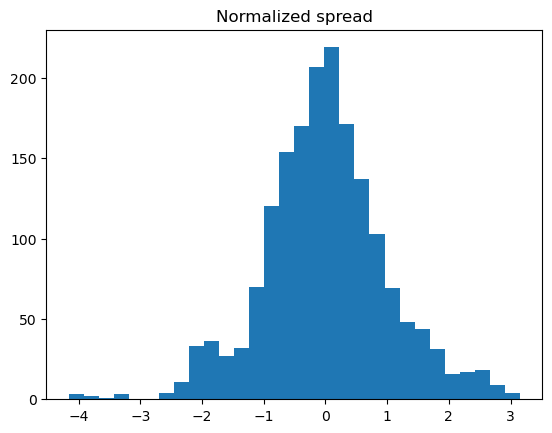

In [106]:
plt.hist(assets["z_score"], bins=30)
plt.title("Normalized spread")
plt.show()

In [107]:
assets['positions_GLD_Long'] = 0
assets['positions_GLD_Short'] = 0
assets['positions_GDX_Long'] = 0
assets['positions_GDX_Short'] = 0

In [108]:
# Entries
assets.loc[assets.z_score >= 2,  ['positions_GLD_Short', 'positions_GDX_Short']] = [-1, 1]
assets.loc[assets.z_score <= -2, ['positions_GLD_Long',  'positions_GDX_Long']]  = [1, -1]

# Exits
assets.loc[assets.z_score <= 1,  ['positions_GLD_Short', 'positions_GDX_Short']] = 0
assets.loc[assets.z_score >= -1, ['positions_GLD_Long',  'positions_GDX_Long']]  = 0

# Fill forward then fill remaining NaNs with 0 (flat before first signal)
assets.ffill(inplace=True)
assets.fillna(0, inplace=True)

In [109]:
positions_Long = assets[['positions_GLD_Long', 'positions_GDX_Long']]
positions_Short = assets[['positions_GLD_Short', 'positions_GDX_Short']]
positions = np.array(positions_Long) + np.array(positions_Short)
positions = pd.DataFrame(positions)

In [110]:
dailyret = assets[['GLD', 'GDX']].pct_change()
pnl = (np.array(positions.shift()) * np.array(dailyret)).sum(axis=1)

In [111]:
pnl = pd.Series(pnl)
pnl_clean = pnl.dropna()

sharpe = np.sqrt(252) * np.mean(pnl_clean) / np.std(pnl_clean)
print(sharpe)

-0.10272573077610525
